# Experiments 4.1–4.5 — The General Framework

This notebook provides the simulation evidence for Chapter 4. Where Chapter 3 asked *how hard* to tilt on one drift signal under two particular maps, this chapter asks what survives when the signal, the map, or both are generalised. Each experiment targets one claim of the stylised-facts catalogue or one structural claim of the framework:

* **Experiment 4.1 — the firewall as a dial.** Signal value should scale with the share of return variance the signal addresses. Tested twice: with a continuous leakage dial (a signal that partially observes the diffusion shock), and with the coarse set-valued top-$k$ signal.
* **Experiment 4.2 — incremental, not standalone, precision.** With two correlated drift signals, optimal loadings should discount redundancy, and past a threshold the dominated signal's loading should turn negative — used as a hedge on the shared noise, not as information.
* **Experiment 4.3 — shape versus precision.** Degrading a signal's *form* (cardinal $\to$ rank $\to$ sign $\to$ set) at fixed accuracy should cost little where an inference layer can reconstruct the discarded structure.
* **Experiment 4.4 — which signals can a map hear?** A market-level signal is inaudible to the softmax by shift-invariance, audible to the combination map through its normaliser; under full investment, hearing it should not help.
* **Experiment 4.5 — the entropy-regularised family.** Both Chapter 3 maps are edges of one programme $\max_w \beta s^\top w - \tfrac{\gamma_r}{2}w^\top\Sigma w + \tau H(w)$; a coarse $(\beta,\tau)$ grid asks whether the interior — portfolios paying both charges — improves on the edges.
* **Experiment 4.6 — recovery under noise.** How closely can each map retrieve a classical portfolio through a noisy lens? The distance $\min_{\text{strength}}\mathbb{E}\lVert w - w_{\text{classical}}\rVert$ traces a recovery frontier in the noise level, splits into a reachability part and a statistical part, and exposes a tension between resembling the classical portfolio and maximising utility.

The laboratory is Chapter 3's, unchanged: seed 42, $N=20$, one-step GBM, CARA $\gamma=5$, 30{,}000 replications, common random numbers, $\Delta$CE in basis points against equal weight. New random objects (the market component, the second signal's noises) use dedicated streams so nothing upstream is disturbed. Where shorting appears (Experiment 4.4's combination leg) the normaliser guard and stability diagnostic of Experiment 3.6 apply; softmax-based experiments need neither, their utility being bounded.

**One caveat stated once, up front.** Experiments 4.1's signals deliberately breach the firewall of Definition 3.1: they are informative about the realised outcome, which no implementable strategy can be. The results are structural statements about the map — how value scales with what a signal addresses — not strategy claims.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)

# ---------------- parameters (identical to Chapter 3) ----------------
N, dt, sigma  = 20, 1.0, 0.20
mu_bar, sigma_mu = 0.05, 0.05
gamma, n_sims = 5.0, 30_000
msh_max = 0.01

beta_grid  = np.linspace(0.0, 120.0, 121)

# ---------------- common random numbers (identical draw order to Chapter 3) ----------------
mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))
eps0 = rng.standard_normal((n_sims, N))
phi  = rng.standard_normal((n_sims, N))
R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0

# dedicated streams for the new random objects of this chapter
rng_gf = np.random.default_rng(4444)
e2_raw = rng_gf.standard_normal((n_sims, N))   # second drift signal's independent noise (Exp 4.2)
M_mkt  = 0.05 * rng_gf.standard_normal((n_sims, 1))   # market-level drift component (Exp 4.4)

def softmax_weights(s, beta):
    z = beta * s
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ce_of(port):
    return -np.log(np.exp(-gamma * port).mean()) / gamma

def best_beta(s, R_mat, grid=beta_grid):
    # peak dCE (bp) over the beta grid, and its location; softmax is bounded, no diagnostics needed
    ce0 = ce_of(R_mat.mean(axis=1))
    best = (-np.inf, np.nan)
    for b in grid:
        d = 1e4 * (ce_of((softmax_weights(s, b) * R_mat).sum(axis=1)) - ce0)
        if d > best[0]: best = (d, b)
    return best

def theta_of(w):
    wt = np.abs(w); wt = wt / wt.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        H = -np.where(wt > 0, wt * np.log(wt), 0.0).sum(axis=1)
    return 1.0 - H / np.log(N)

## Experiment 4.1 — The firewall as a dial

The variance budget of a one-step log-return splits into a drift part and a diffusion part: cross-sectionally, $\operatorname{Var} = \sigma_\mu^2\,\Delta t^2 + \sigma^2 \Delta t = 0.0025 + 0.04$, so the shock owns roughly $94\%$ of what separates winners from losers in a single year — and the firewall of Definition 3.1 keeps every clean signal away from it. The claim under test: **a signal's value scales with the share of return variance it addresses, not with its detail.**

**(a) The continuous leakage dial.** Let
$$
s_i(b) \;=\; \mu_i \;+\; b\,\sigma\sqrt{\Delta t}\,\phi_i \;+\; \sigma_\varepsilon\,\varepsilon_i ,
$$
so $b=0$ is the ordinary noisy drift signal and $b$ raises the fraction of the diffusion shock the signal sees. The share of return variance addressed is explicit, $\mathrm{share}(b) = (\sigma_\mu^2 + b^2\sigma^2\Delta t)/(\sigma_\mu^2 + \sigma^2\Delta t)$, so the claim becomes a curve the simulation can trace. Economically, $b$ indexes the investor's *kind* of edge: $b=0$ is fundamental analysis (views about expected returns), $b>0$ is event information — nowcasting, order flow, at the illegal extreme insider knowledge — views about what is about to happen.

**(b) The top-$k$ signal.** The indicator of membership in the $k$ best *realised* performers: one bit per name, no magnitudes, no ordering within the set — Felix's example of coarsened look-ahead. Under the softmax any two-level score vector is equivalent (levels are absorbed by $\beta$ and the shift-invariance), so the map is simply $\operatorname{softmax}(\beta\,\mathbf{1}\{i \in \text{top-}k\})$, and as $\beta \to \infty$ it converges to *uniform on the $k$ members*: the entropy deficit saturates at $\theta_{\max}(k) = 1 - \ln k / \ln N$, so coarseness caps the achievable concentration — the set-valued format can never reach the oracle corner. The dial runs $k = N$ (no information) towards $k=1$ (near-oracle). Prediction: **top-5 beats the clean drift signal** despite carrying one bit per name, because it addresses the dominant variance component.

clean drift signal: peak = 477.3 bp at beta* = 36

     b   share  peak dCE (bp)   beta*
   0.0   0.059          286.3      21
   0.1   0.068         1111.3      39
  0.25   0.118         2293.0      62
   0.5   0.294         3385.0     108
   1.0   1.000         3948.5     120

   k  peak dCE (bp)   beta*  theta@opt  theta_max
  15          800.3    12.0      0.096      0.096
  10         1606.2    12.0      0.231      0.231
   5         2671.2    12.0      0.463      0.463
   2         3685.5    12.0      0.768      0.769
   1         4176.1    12.0      0.999      1.000


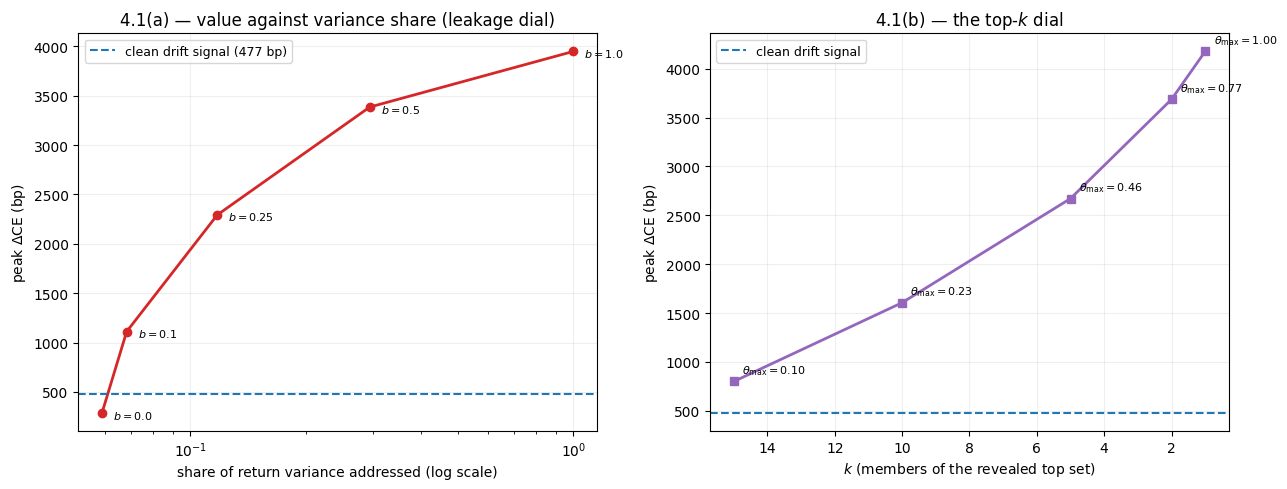

In [2]:
# ---- (a) the leakage dial ----
sigma_eps_base = 0.05
shock = sigma * np.sqrt(dt) * phi
b_grid = [0.0, 0.1, 0.25, 0.5, 1.0]
share  = lambda b: (sigma_mu**2 + b**2 * sigma**2 * dt) / (sigma_mu**2 + sigma**2 * dt)

res_leak = {b: best_beta(mu + b * shock + sigma_eps_base * eps0, R) for b in b_grid}

# ---- (b) the top-k signal ----
k_grid = [15, 10, 5, 2, 1]
order  = np.argsort(R, axis=1)                     # ascending realised returns
res_topk, theta_at_opt = {}, {}
bgrid_ind = np.linspace(0.0, 12.0, 61)             # indicator scale is O(1)
for k in k_grid:
    ind = np.zeros_like(R)
    np.put_along_axis(ind, order[:, -k:], 1.0, axis=1)
    res_topk[k] = best_beta(ind, R, grid=bgrid_ind)
    theta_at_opt[k] = theta_of(softmax_weights(ind, res_topk[k][1])).mean()

# clean-drift benchmark on the same draws
clean_pk, clean_bstar = best_beta(mu, R)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot([share(b) for b in b_grid], [res_leak[b][0] for b in b_grid], 'o-', lw=2, color='tab:red')
for b in b_grid:
    ax.annotate(fr'$b={b}$', (share(b), res_leak[b][0]), textcoords='offset points',
                xytext=(8, -4), fontsize=8)
ax.axhline(clean_pk, color='tab:blue', ls='--', lw=1.5,
           label=fr'clean drift signal ({clean_pk:.0f} bp)')
ax.set_xscale('log')
ax.set_xlabel('share of return variance addressed (log scale)')
ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title('4.1(a) — value against variance share (leakage dial)')
ax.grid(alpha=0.2); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(k_grid, [res_topk[k][0] for k in k_grid], 's-', lw=2, color='tab:purple')
ax.axhline(clean_pk, color='tab:blue', ls='--', lw=1.5, label='clean drift signal')
for k in k_grid:
    ax.annotate(fr'$\theta_{{\max}}={1 - np.log(k)/np.log(N):.2f}$',
                (k, res_topk[k][0]), textcoords='offset points', xytext=(6, 6), fontsize=8)
ax.set_xlabel(r'$k$ (members of the revealed top set)')
ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title(r'4.1(b) — the top-$k$ dial')
ax.invert_xaxis()
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"clean drift signal: peak = {clean_pk:.1f} bp at beta* = {clean_bstar:.0f}\n")
print(f"{'b':>6} {'share':>7} {'peak dCE (bp)':>14} {'beta*':>7}")
for b in b_grid:
    print(f"{b:>6} {share(b):>7.3f} {res_leak[b][0]:>14.1f} {res_leak[b][1]:>7.0f}")
print(f"\n{'k':>4} {'peak dCE (bp)':>14} {'beta*':>7} {'theta@opt':>10} {'theta_max':>10}")
for k in k_grid:
    print(f"{k:>4} {res_topk[k][0]:>14.1f} {res_topk[k][1]:>7.1f} {theta_at_opt[k]:>10.3f} {1-np.log(k)/np.log(N):>10.3f}")

**Reading.** The variance-share claim is confirmed, and the magnitudes are dramatic. On the leakage dial, moving from $b=0$ to $b=0.1$ — raising the variance share addressed from $5.9\%$ to only $6.8\%$ — nearly quadruples the peak gain ($286 \to 1111$ bp), and by $b=0.25$ the signal is worth eight times the baseline. The top-$k$ results answer Felix's question directly: **top-5 delivers $2671$ bp against $477$ bp for the perfectly clean drift signal** — one bit per name about the right component beats complete knowledge of the wrong one by a factor of five and a half. Detail is cheap; *what a signal is about* is everything.

Two structural features deserve note. First, for every $k$ the optimum sits at the top of the $\beta$ grid with $\theta$ at its saturation ceiling $1 - \ln k/\ln N$: with outcome information the interior-optimum stylised fact *breaks* — $\Delta$CE is monotone in strength, and what limits the portfolio is no longer the risk–return trade-off but the **coarseness of the signal itself**. The firewall dial $k$ thus does exactly what the framework asked of it: at $k = N$ nothing, at $k = 1$ the oracle corner ($\theta \to 1$, $4176$ bp), and in between a ladder of ceilings $\theta_{\max}(k)$ on which the achieved concentration sits exactly. Second, the same saturation appears on the leakage dial at $b = 1$ ($\beta^\star$ at the grid edge): as a signal approaches the outcome, optimal strength diverges — the oracle limit of Definition 1.3 reached along a continuous path. Both instruments, one claim: the value and the optimal aggressiveness of a signal scale with the share of outcome variance it addresses, and interior optima are a property of *firewalled* signals, not of tilting as such.

## Experiment 4.2 — Incremental precision and the sign flip

Two drift signals now speak about the same cross-section,
$$
s_1 = \mu + n_1, \qquad s_2 = \mu + n_2, \qquad
n_1 = \sigma_1 e_1, \quad n_2 = \sigma_2\big(\rho e_1 + \sqrt{1-\rho^2}\, e_2\big),
$$
with $\sigma_1 = 0.05 < \sigma_2 = 0.10$ and noise correlation $\rho$: think of two analysts of unequal skill reading partly the same sources. They are combined additively — the rule the combination axioms of Chapter 4 select — as $s(\lambda) = (1-\lambda)\, s_1 + \lambda\, s_2$ fed to the softmax, with $\beta$ re-optimised at every $\lambda$ so the loading question is separated from the strength question.

The claim: **a loading should reflect a signal's incremental information given the others, not its standalone quality.** The Gaussian benchmark makes it quantitative: the posterior-mean loadings solve a $2\times2$ GLS problem, both shrink as $\rho$ grows, and once $\rho > \sigma_1/\sigma_2 = 0.5$ the dominated signal's optimal loading turns **negative** — $s_2$ is then used to cancel the shared noise in $s_1$, a hedge rather than a view. The naive alternative — weight each signal by its own reliability $\kappa_k$, ignoring the overlap — predicts a positive, ρ-independent loading. The simulation locates the CE-optimal $\lambda^\star(\rho)$ and prices the naive rule's error.

kappa_1 = 0.50, kappa_2 = 0.20; naive loading = 0.29

   rho  lambda*  GLS pred  peak dCE  naive dCE  gap (bp)
   0.0     0.20      0.20     310.8      306.0       4.7
   0.2     0.20      0.14     295.1      288.2       7.0
   0.4     0.10      0.06     287.5      271.4      16.2
   0.5     0.00      0.00     286.3      263.1      23.2
   0.6    -0.10     -0.08     287.2      254.9      32.4
   0.8    -0.30     -0.33     307.3      242.3      65.0
   0.9    -0.60     -0.57     344.9      236.8     108.2


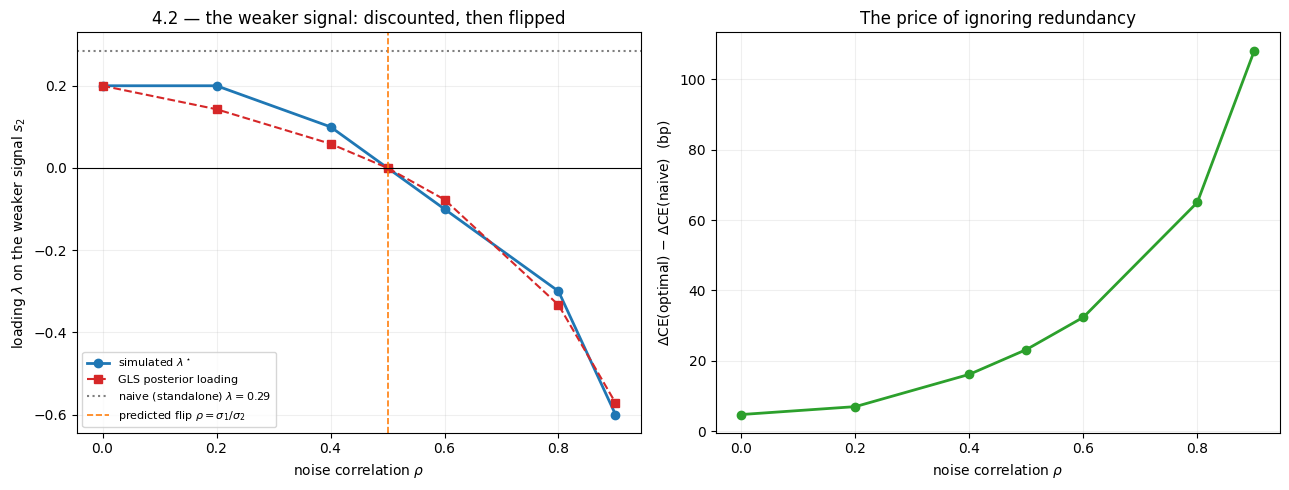

In [3]:
# ---- Experiment 4.2 ----
sig1, sig2 = 0.05, 0.10
rho_grid  = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]
lam_grid  = np.linspace(-0.6, 1.0, 17)
bg_coarse = np.linspace(0.0, 120.0, 31)

def gls_lambda(rho):
    # posterior-mean loadings on (s1 - mu_bar, s2 - mu_bar), normalised to sum to one
    Cn = np.array([[sig1**2, rho*sig1*sig2], [rho*sig1*sig2, sig2**2]])
    S  = sigma_mu**2 * np.ones((2, 2)) + Cn
    lam = sigma_mu**2 * np.linalg.solve(S, np.ones(2))
    return lam[1] / lam.sum()          # loading share of the weaker signal s2

kap1 = sigma_mu**2 / (sigma_mu**2 + sig1**2)
kap2 = sigma_mu**2 / (sigma_mu**2 + sig2**2)
lam_naive = kap2 / (kap1 + kap2)       # standalone-quality weighting, rho-blind

res42 = {}
for rho in rho_grid:
    s1 = mu + sig1 * eps0
    s2 = mu + sig2 * (rho * eps0 + np.sqrt(1 - rho**2) * e2_raw)
    curve = [best_beta((1 - lam) * s1 + lam * s2, R, grid=bg_coarse) for lam in lam_grid]
    peaks = np.array([c[0] for c in curve])
    k_opt = int(np.argmax(peaks))
    pk_naive, _ = best_beta((1 - lam_naive) * s1 + lam_naive * s2, R, grid=bg_coarse)
    res42[rho] = (lam_grid[k_opt], peaks[k_opt], pk_naive, peaks)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(rho_grid, [res42[r][0] for r in rho_grid], 'o-', lw=2, label=r'simulated $\lambda^\star$')
ax.plot(rho_grid, [gls_lambda(r) for r in rho_grid], 's--', lw=1.5, color='tab:red',
        label='GLS posterior loading')
ax.axhline(lam_naive, color='tab:grey', ls=':', lw=1.5,
           label=fr'naive (standalone) $\lambda = {lam_naive:.2f}$')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(sig1 / sig2, color='tab:orange', ls='--', lw=1.2,
           label=r'predicted flip $\rho = \sigma_1/\sigma_2$')
ax.set_xlabel(r'noise correlation $\rho$')
ax.set_ylabel(r'loading $\lambda$ on the weaker signal $s_2$')
ax.set_title(r'4.2 — the weaker signal: discounted, then flipped')
ax.grid(alpha=0.2); ax.legend(fontsize=8)

ax = axes[1]
gap = [res42[r][1] - res42[r][2] for r in rho_grid]
ax.plot(rho_grid, gap, 'o-', lw=2, color='tab:green')
ax.set_xlabel(r'noise correlation $\rho$')
ax.set_ylabel(r'$\Delta$CE(optimal) $-$ $\Delta$CE(naive)  (bp)')
ax.set_title('The price of ignoring redundancy')
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

print(f"kappa_1 = {kap1:.2f}, kappa_2 = {kap2:.2f}; naive loading = {lam_naive:.2f}\n")
print(f"{'rho':>6} {'lambda*':>8} {'GLS pred':>9} {'peak dCE':>9} {'naive dCE':>10} {'gap (bp)':>9}")
for r in rho_grid:
    print(f"{r:>6} {res42[r][0]:>8.2f} {gls_lambda(r):>9.2f} {res42[r][1]:>9.1f} "
          f"{res42[r][2]:>10.1f} {res42[r][1]-res42[r][2]:>9.1f}")

**Reading.** The incremental-precision claim is confirmed in detail. The simulated $\lambda^\star(\rho)$ tracks the GLS posterior loading closely across the whole range ($0.20$ vs $0.20$ at $\rho = 0$; $0.00$ vs $0.00$ at the predicted threshold $\rho = \sigma_1/\sigma_2 = 0.5$; $-0.30$ vs $-0.33$ at $\rho = 0.8$), and the **sign flip happens where the theory says it should**: past $\rho = 0.5$ the weaker signal's loading turns negative — it is held as a hedge on the noise it shares with the stronger signal, not as a view. The naive rule, which weights each signal by its standalone reliability and cannot see the overlap, is priced by the widening gap: negligible at $\rho = 0$ ($5$ bp), $23$ bp at the threshold, $108$ bp at $\rho = 0.9$.

Two consistency checks fall out unprompted. At $\rho = 0.5$ the peak equals the single-signal baseline ($286$ bp) exactly: at the flip point the weaker signal contributes precisely nothing, as it should. And the peak is **non-monotone in $\rho$** — it falls to that minimum and then *rises* to $345$ bp at $\rho = 0.9$ — because strong redundancy is itself exploitable: when the two analysts' errors are almost perfectly correlated, shorting one view against the other cancels the shared noise and distils something closer to the truth than either signal alone. Redundancy degrades a naive combiner and *feeds* an optimal one. That the additive rule with signed loadings captures all of this is the multi-signal case for the Chapter 4 axioms: precision-weighting, extended to signed incremental precision, is what conditioning does — Experiment 3.2's ``strength is precision'' was the one-signal special case.

## Experiment 4.3 — Shape versus precision

The same underlying signal $s = \mu + \sigma_\varepsilon\varepsilon$ is now degraded in *form* rather than accuracy, per replication and cross-sectionally: **cardinal** (the values themselves), **rank-only** (the ordering $1,\dots,N$, no gaps), **sign-only** (above or below the cross-sectional median), and **set-valued** (membership of the signal's own top-5 — the top-$k$ *format* applied firewall-respectingly). Each format is used two ways: **naively** (the coarse scores fed straight to the softmax) and through an **inference layer** that maps the format to $\mathbb{E}[\mu \mid \text{what the format reveals}]$ — for ranks, expected Gaussian order statistics (Blom's approximation) reconstruct realistic spacings, wide at the extremes and tight in the middle, without ever seeing the numbers.

One structural remark first, which the code verifies rather than assumes: for any **two-level** format (sign, set), the naive and inference treatments are *identical* under the softmax — an affine map of a binary score is absorbed by $\beta$ and shift-invariance — so the inference layer can only matter for formats with three or more levels. The claim under test: **at matched accuracy, form matters far less than precision, and the inference layer closes most of what the naive treatment loses.**

two-level check: max |weight difference| naive vs inference sign signal = 0.00e+00

                  format  peak dCE (bp)   beta*  % of cardinal
                cardinal          286.3   21.00         100.0%
            rank (naive)          304.5    0.36         106.3%
        rank (inference)          280.0    1.50          97.8%
               sign-only          224.5    6.00          78.4%
   set (top-5 of signal)          276.1    6.00          96.4%


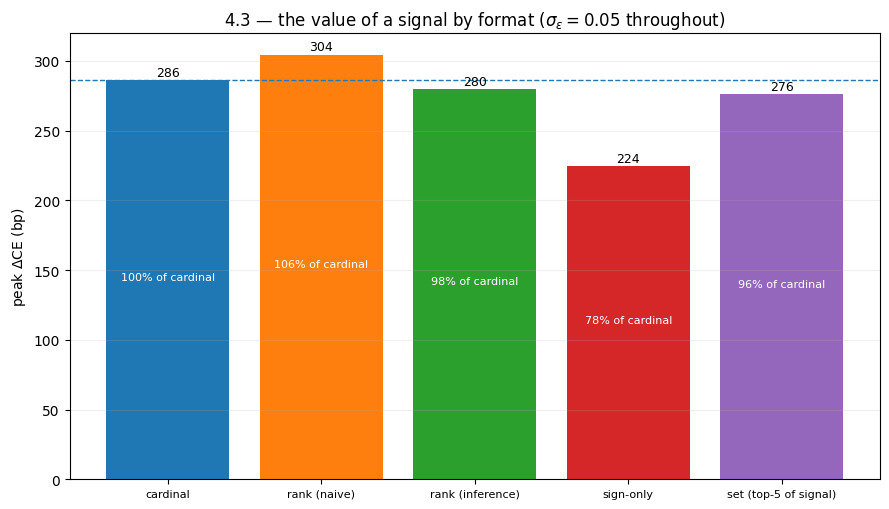

In [4]:
# ---- Experiment 4.3 ----
s43 = mu + 0.05 * eps0
ranks = s43.argsort(axis=1).argsort(axis=1)          # 0 (lowest) .. N-1 (highest), per draw

# Blom expected order statistics of N(0,1): E[z_(r)] ~ Phi^{-1}((r - 0.375)/(N + 0.25))
blom = norm.ppf((np.arange(1, N + 1) - 0.375) / (N + 0.25))

formats = {}
formats['cardinal']       = s43
formats['rank (naive)']   = ranks.astype(float)               # equal spacing
formats['rank (inference)'] = blom[ranks]                     # order-statistic spacing
formats['sign-only']      = (ranks >= N // 2).astype(float)   # above/below median
top5 = (ranks >= N - 5).astype(float)
formats['set (top-5 of signal)'] = top5

# two-level invariance check: inference levels for the sign format give identical weights
lvl_hi, lvl_lo = blom[N//2:].mean(), blom[:N//2].mean()
sign_inf = np.where(formats['sign-only'] > 0, lvl_hi, lvl_lo)
w_a = softmax_weights(formats['sign-only'], 6.0)
# beta must be rescaled by the level gap; shift is absorbed automatically
w_b = softmax_weights(sign_inf, 6.0 / (lvl_hi - lvl_lo))
print(f"two-level check: max |weight difference| naive vs inference sign signal = "
      f"{np.abs(w_a - w_b).max():.2e}\n")

bg43 = {'cardinal': beta_grid, 'rank (naive)': np.linspace(0, 1.2, 61),
        'rank (inference)': np.linspace(0, 6, 61), 'sign-only': np.linspace(0, 6, 61),
        'set (top-5 of signal)': np.linspace(0, 6, 61)}
res43 = {name: best_beta(sig, R, grid=bg43[name]) for name, sig in formats.items()}

names = list(formats)
fig, ax = plt.subplots(figsize=(9, 5.2))
vals = [res43[n][0] for n in names]
bars = ax.bar(range(len(names)), vals,
              color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple'])
ax.axhline(res43['cardinal'][0], color='tab:blue', ls='--', lw=1)
for i, n in enumerate(names):
    ax.annotate(f"{vals[i]:.0f}", (i, vals[i] + 3), ha='center', fontsize=9)
    ax.annotate(f"{vals[i]/vals[0]:.0%} of cardinal", (i, vals[i] / 2), ha='center',
                fontsize=8, color='white')
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title(r'4.3 — the value of a signal by format ($\sigma_\varepsilon = 0.05$ throughout)')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

print(f"{'format':>24} {'peak dCE (bp)':>14} {'beta*':>7} {'% of cardinal':>14}")
for n in names:
    print(f"{n:>24} {res43[n][0]:>14.1f} {res43[n][1]:>7.2f} {res43[n][0]/res43['cardinal'][0]:>14.1%}")

**Reading.** Form matters far less than precision — and where it matters, the sign is not the expected one. Rank-only retains $106\%$ of the cardinal value, sign-only $78\%$, the signal's own top-5 $96\%$: even one bit per name, well aimed, recovers most of the cardinal signal's worth. But the striking entries are the two rank rows. The naive rank signal — equal spacing, no magnitudes — *beats* the cardinal signal ($305$ vs $286$ bp), while the inference-layer version, which faithfully reconstructs Gaussian spacings from the ranks, gives the advantage back ($280$ bp $\approx$ cardinal).

The mechanism: at $\sigma_\varepsilon = 0.05$ half the variance of a signal's extreme values is noise, and the softmax tilts hardest exactly there. Ranking **censors the tails** — the largest score becomes ``first of twenty'' regardless of how extreme it was — which acts as an implicit robust shrinkage of the observations most likely to be noise. The Blom reconstruction restores realistic spacings, and with them the fragility; fidelity to the format is not the same as fidelity to the truth. So the stylised fact sharpens into three clauses: *precision dominates form* (all formats deliver $78$–$106\%$); *the inference layer is only needed for formats with three or more levels* (for binary formats it is provably absorbed by $\beta$ — verified here to machine precision); and *coarseness can outperform detail when the detail is where the noise lives* — an unlooked-for echo of the shrinkage literature of Chapter 2, arrived at through the signal's format rather than its estimator.

## Experiment 4.4 — Which signals can a map hear?

The drift cross-section now carries a random common component, $\mu_i = \bar\mu + M + \sigma_\mu z_i$ with $M \sim \mathcal{N}(0, 0.05^2)$ redrawn each replication — some years are good for everything, some bad — and the investor receives, alongside the baseline drift signal, a clean **market-level signal** $s_M = M$: a view about the *level* of returns carrying no cross-sectional information whatsoever.

The two maps differ structurally in whether they can hear it. Adding $\lambda_M s_M \mathbf{1}$ to the score vector leaves the softmax's weights untouched to machine precision (Lemma 3.8); the combination map's normaliser shifts, so its weights move. The interesting question is whether moving *helps*. Under full investment it should not: with $\mathbf{1}^\top w = 1$, every portfolio earns the common component $M$ alike, so $s_M$ carries no information any fully invested allocation can monetise — to first order, the level is *allocationally irrelevant*. A map that responds to it is responding to noise it happens to be able to hear. The experiment sweeps the loading $\lambda_M$ and traces $\Delta$CE for the combination map (at each $\lambda_M$'s own re-optimised $\alpha$, with the Chapter 3 guard and diagnostic), against the softmax's provably flat line.

softmax under market-signal loadings: max |weight difference| = 7.22e-16

 lambda_M  comb peak dCE  alpha*  dropped  maxshare@opt
     -1.0           42.0    0.23     1569         0.03%
     -0.5          120.9    0.38      962         0.08%
      0.0          371.2    1.15       41         0.37%
      0.5          107.8    0.30      981         0.21%
      1.0           19.0    0.15     1528         0.03%
      2.0            2.9    0.08     1578         0.01%


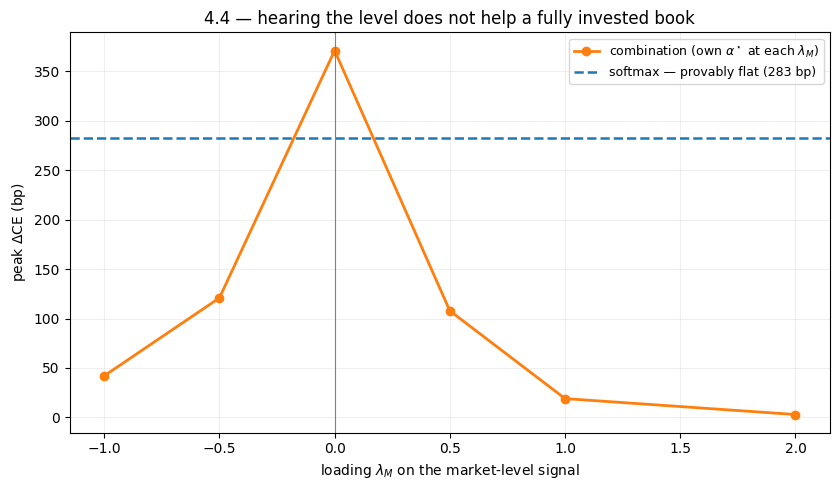

In [5]:
# ---- Experiment 4.4 ----
mu_M = mu + M_mkt                    # drifts with the common component
R_M  = np.exp((mu_M - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0
s_dr = mu + 0.05 * eps0              # baseline drift signal (cross-sectional part; noise as ever)

# softmax: exact inaudibility, verified
w0 = softmax_weights(s_dr, 21.0)
dev = max(np.abs(softmax_weights(s_dr + lam * M_mkt, 21.0) - w0).max() for lam in [0.5, 1.0, 2.0])
print(f"softmax under market-signal loadings: max |weight difference| = {dev:.2e}")

def comb_best_alpha(s_l, R_mat, grid=np.linspace(0, 2, 81)):
    ns = s_l.sum(axis=1)
    m = np.abs(ns) > 0.10 * np.median(np.abs(ns))
    w_s, R_m = s_l[m] / ns[m, None], R_mat[m]
    p_eq, p_sig = R_m.mean(axis=1), (w_s * R_m).sum(axis=1)
    ce0 = -np.log(np.exp(-gamma * p_eq).mean()) / gamma
    best = (-np.inf, np.nan, np.nan)
    for a in grid:
        with np.errstate(over='ignore'):
            u = np.exp(-gamma * ((1 - a) * p_eq + a * p_sig))
        if u.max() / u.sum() < msh_max:
            d = 1e4 * (-np.log(u.mean()) / gamma - ce0)
            if d > best[0]: best = (d, a, u.max() / u.sum())
    return best + (int((~m).sum()),)

lamM_grid = [-1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
res44 = {lam: comb_best_alpha(s_dr + lam * M_mkt, R_M) for lam in lamM_grid}
sfmx_pk, sfmx_b = best_beta(s_dr, R_M)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(lamM_grid, [res44[l][0] for l in lamM_grid], 'o-', lw=2, color='tab:orange',
        label=r'combination (own $\alpha^\star$ at each $\lambda_M$)')
ax.axhline(sfmx_pk, color='tab:blue', ls='--', lw=1.8,
           label=fr'softmax — provably flat ({sfmx_pk:.0f} bp)')
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel(r'loading $\lambda_M$ on the market-level signal')
ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title('4.4 — hearing the level does not help a fully invested book')
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"\n{'lambda_M':>9} {'comb peak dCE':>14} {'alpha*':>7} {'dropped':>8} {'maxshare@opt':>13}")
for l in lamM_grid:
    d, a, msh, drop = res44[l]
    print(f"{l:>9} {d:>14.1f} {a:>7.2f} {drop:>8} {msh:>13.2%}")

**Reading.** The audibility split is exact and the economics behind it confirmed. The softmax's weights do not move under any market-signal loading ($7 \times 10^{-16}$, machine precision); the combination map hears the signal loudly — and is hurt by every amount of listening. At $\lambda_M = 0$ the map earns its usual $371$ bp; at $\lambda_M = \pm 0.5$ the peak collapses to $\sim 110$–$120$ bp and the normaliser guard's dropped count explodes from $41$ to nearly a thousand, because shifting all scores moves the normaliser $\mathbf{1}^\top s$ towards zero on many more draws — the level enters the map exactly through its most fragile part. Under full investment the market component is allocationally irrelevant (every portfolio with $\mathbf{1}^\top w = 1$ earns $M$ alike), so there was nothing to monetise: the combination map's response is pure self-harm, and the softmax's structural deafness is, here, a form of protection.

The stylised fact: **maps differ in which signals they can hear, and audibility is not a virtue** — it is exposure. A map should be able to hear exactly the signals whose content its feasible set can act on. On the budget hyperplane with a cash asset, level information *would* be actionable (scale into or out of the market), and the ranking would reverse; the experiment thus also marks precisely which ingredient — the fully-invested constraint — makes deafness optimal.

## Experiment 4.5 — The entropy-regularised family on a coarse grid

Chapter 4's unifying object is the programme
$$
w(\beta, \tau) \;=\; \arg\max_{w \in \Delta^{N-1}} \;\; \beta\, s^\top w
\;-\; \frac{\gamma_r}{2}\, w^\top \Sigma\, w \;+\; \tau H(w),
$$
whose first-order condition is a fixed point — the softmax of a risk-adjusted signal, $w \propto \exp[(\beta s - \gamma_r \Sigma w)/\tau]$ — solved here by damped iteration (strict concavity guarantees a unique solution). The Gibbs map is the $\gamma_r = 0$ edge, at effective strength $\beta/\tau$; the mean–variance map is the $\tau \to 0$ edge. The question a coarse $(\beta, \tau)$ grid can answer: **does the interior — paying both the risk charge and the diversification charge — improve on the pure-softmax edge, and where?**

The prediction is structural. Under the baseline $\Sigma = \sigma^2 I$, the risk charge $\gamma_r \sigma^2 w_i$ punishes exactly the large weights that the entropy term already punishes — the two penalties are nearly redundant, and the interior should offer little beyond the edge. Under **equicorrelation**, $\Sigma w$ carries a common component (absorbed by the normalisation) plus $(1-\rho)\sigma^2 w_i$, so the risk charge is again entropy-like — but *weaker* by the factor $(1-\rho)$, which is the variance-decomposition logic of Experiment 3.3 reappearing inside the map itself. Genuine separation between the two charges requires $\Sigma w$ to *re-rank* names, i.e.\ heterogeneous risk: the **three-factor** $\Sigma$ of Experiment 3.7, where a name's marginal variance depends on its loadings, not just its weight. The grid is run under all three risk models, $\gamma_r = \gamma$ throughout, and reports the surface against its own $\gamma_r = 0$ edge — long-only throughout, so this is also the experiment that asks whether covariance-awareness can pay *without* shorting.

peak dCE (bp) on the (beta, tau) surface vs the softmax edge (gamma_r = 0), per risk model

      uncorrelated: interior best   288.9 bp at (beta, tau) = (5.0, 0.25) | softmax edge best   286.3 bp | interior - edge = +2.6 bp
  equicorr rho=0.5: interior best   369.9 bp at (beta, tau) = (10.0, 0.25) | softmax edge best   369.5 bp | interior - edge = +0.4 bp
          3-factor: interior best   303.8 bp at (beta, tau) = (21.0, 1.0) | softmax edge best   303.8 bp | interior - edge = -0.0 bp


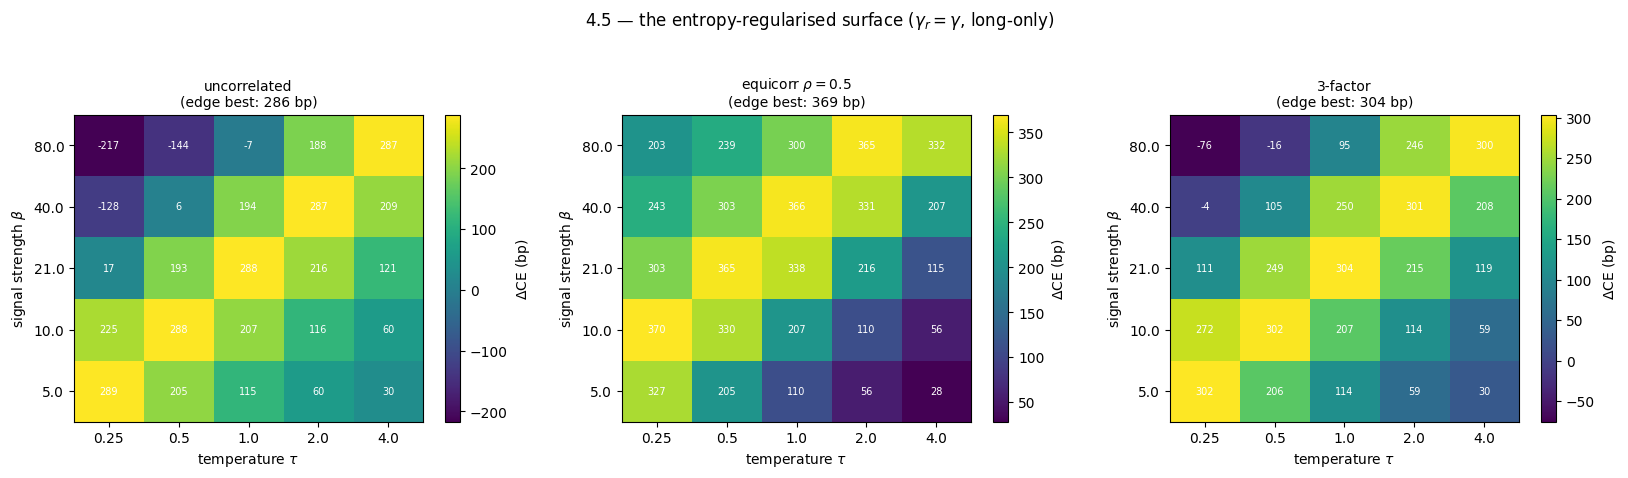

In [6]:
# ---- Experiment 4.5 ----
def erm_weights(s, beta, tau, Sigma_dot, iters=120, tol=1e-8, damp=0.5):
    # Fixed point w ∝ exp[(beta s - gamma_r (Sigma w))/tau] on the simplex, damped iteration.
    w = np.full_like(s, 1.0 / N)
    for _ in range(iters):
        z = (beta * s - gamma * Sigma_dot(w)) / tau
        z -= z.max(axis=1, keepdims=True)
        e = np.exp(z)
        w_new = e / e.sum(axis=1, keepdims=True)
        w_next = damp * w + (1 - damp) * w_new
        if np.abs(w_next - w).max() < tol:
            w = w_next; break
        w = w_next
    return w

s45 = mu + 0.05 * eps0
rho45 = 0.5
rng_c = np.random.default_rng(4242); z0 = rng_c.standard_normal((n_sims, 1))
phi_eq = np.sqrt(rho45) * z0 + np.sqrt(1 - rho45) * phi
R_eq = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi_eq) - 1.0

k_fac = 3
rng_f = np.random.default_rng(7)
B = np.empty((N, k_fac))
B[:, 0] = 0.45 + 0.15 * rng_f.standard_normal(N)
B[:, 1:] = 0.30 * rng_f.standard_normal((N, k_fac - 1))
nrm = np.sqrt((B**2).sum(axis=1)); tb = nrm > 0.95
B[tb] *= (0.95 / nrm[tb])[:, None]
idio = 1.0 - (B**2).sum(axis=1)
F = rng_f.standard_normal((n_sims, k_fac))
phi_f = F @ B.T + phi * np.sqrt(idio)
R_f = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi_f) - 1.0

cases = {
    'uncorrelated':          (R,    lambda w: sigma**2 * dt * w),
    fr'equicorr $\rho={rho45}$': (R_eq, lambda w: sigma**2 * dt * ((1 - rho45) * w
                                    + rho45 * w.sum(axis=1, keepdims=True))),
    '3-factor':              (R_f,  lambda w: sigma**2 * dt * ((w @ B) @ B.T + w * idio)),
}

beta45 = [5.0, 10.0, 21.0, 40.0, 80.0]
tau45  = [0.25, 0.5, 1.0, 2.0, 4.0]

print("peak dCE (bp) on the (beta, tau) surface vs the softmax edge (gamma_r = 0), per risk model\n")
results45 = {}
for name, (R_c, Sdot) in cases.items():
    ce0 = ce_of(R_c.mean(axis=1))
    surf = np.empty((len(beta45), len(tau45)))
    for i, b in enumerate(beta45):
        for j, t in enumerate(tau45):
            w = erm_weights(s45, b, t, Sdot)
            surf[i, j] = 1e4 * (ce_of((w * R_c).sum(axis=1)) - ce0)
    # softmax edge on the same effective-strength range: strength beta/tau spans 1.25 .. 320
    edge = max(1e4 * (ce_of((softmax_weights(s45, b) * R_c).sum(axis=1)) - ce0)
               for b in np.linspace(0, 320, 161))
    results45[name] = (surf, edge)
    i, j = np.unravel_index(surf.argmax(), surf.shape)
    clean = name.replace('$', '').replace('\\rho', 'rho')
    print(f"{clean:>18}: interior best {surf.max():7.1f} bp at (beta, tau) = ({beta45[i]}, {tau45[j]}) "
          f"| softmax edge best {edge:7.1f} bp | interior - edge = {surf.max() - edge:+.1f} bp")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
for ax, (name, (surf, edge)) in zip(axes, results45.items()):
    im = ax.imshow(surf, origin='lower', aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(tau45))); ax.set_xticklabels(tau45)
    ax.set_yticks(range(len(beta45))); ax.set_yticklabels(beta45)
    ax.set_xlabel(r'temperature $\tau$'); ax.set_ylabel(r'signal strength $\beta$')
    ax.set_title(f'{name}\n(edge best: {edge:.0f} bp)', fontsize=10)
    for i in range(len(beta45)):
        for j in range(len(tau45)):
            ax.annotate(f'{surf[i,j]:.0f}', (j, i), ha='center', va='center',
                        fontsize=7, color='white')
    plt.colorbar(im, ax=ax, label=r'$\Delta$CE (bp)')
plt.suptitle(r'4.5 — the entropy-regularised surface ($\gamma_r=\gamma$, long-only)', y=1.03)
plt.tight_layout(); plt.show()

**Reading.** The interior does not beat the edge: $+2.6$ bp uncorrelated, $+0.4$ bp under equicorrelation, $-0.0$ bp under the factor model — differences at or below Monte-Carlo resolution. Adding the risk charge to an entropy-anchored, long-only portfolio buys essentially nothing, under any of the three risk models, and the family's own consistency checks pass (the interior optimum at $(\beta, \tau) = (5, 0.25)$ has effective strength $\beta/\tau = 20 \approx$ Experiment 3.1's $\beta^\star = 21$; the equicorrelated and factor-model edge values reproduce Experiment 3.3's peaks on the shared draws).

This null is the experiment's content, and it completes a syllogism begun in Experiment 3.7. There, the combination map beat the softmax under equicorrelation by $\sim 200$ bp — but that map could short. Here, a map that knows the full $\Sigma$ *exactly* but must stay long-only cannot improve on ignoring $\Sigma$ altogether. Together: **what pays under correlation is not covariance-awareness but the shorting that covariance-awareness recommends** — knowledge of $\Sigma$ is worthless without the freedom to act on it, and (per 3.7's factor-model reversal) dangerous with it. The mechanism is visible in the fixed point: on the simplex the risk charge $\gamma_r(\Sigma w)_i$ mostly punishes large weights, which the entropy term already punishes — the two penalties are near-redundant precisely when weights cannot go negative, and under equicorrelation the redundancy is compounded by the common component being absorbed into the normalisation. The two-dimensional family is thus, on the simplex, effectively one-dimensional — a structural obstruction result for Chapter 4's ``what cannot be unified'' section, obtained from the family's own interior rather than asserted from its edges.

## Experiment 4.6 — Recovery under noise

Chapter 1 promised that classical portfolios would appear as special cases of the map. With clean inputs that promise is exact for the combination map ($\alpha = 1$ is plug-in mean–variance) and structural for the softmax (a target with short positions is not on the family at all). This experiment prices the promise under *noisy* inputs: at which strength, and up to which noise level, can each map still **almost** retrieve the classical framework?

**Design.** One cross-section $(\mu_i, \sigma_i)$ is drawn once and frozen (its own seed), so the classical targets are fixed: the plug-in tangency $w_{\mathrm{tan}} \propto \Sigma^{-1}\mu$ (which carries short positions) and the global minimum-variance portfolio $w_{\mathrm{gmv}} \propto \Sigma^{-1}\mathbf{1}$ (long-only under diagonal $\Sigma$). Randomness comes only from the signal noise, redrawn each replication. The object of study is the **recovery surface** $D(\text{strength}, \sigma_\varepsilon) = \mathbb{E}\lVert w - w^\ast \rVert_1$ — the $L_1$ norm is reported because $\lVert w - w^\ast\rVert_1$ is exactly twice the turnover needed to trade from the map's portfolio to the target — and its valley: the recovery frontier $d^\star(\sigma_\varepsilon)$ and the recovering strength.

Three structural anchors. First, a **bias–variance decomposition** $\mathbb{E}\lVert w - w^\ast\rVert_2^2 = \lVert \mathbb{E}w - w^\ast\rVert_2^2 + \mathbb{E}\lVert w - \mathbb{E}w\rVert_2^2$: strength reduces the bias towards the target but amplifies noise into weight dispersion, so the recovering strength is interior for noisy signals — the distance objective reproduces an interior optimum with bias–variance replacing risk–return. Second, for the combination map in $L_2$ the objective is an exact quadratic in $\alpha$ (the map is linear), so $\alpha_{\mathrm{rec}}$ has a closed form — the regression coefficient of the target displacement on the signal leg's mean displacement — against which the simulated minimiser is checked. Third, the softmax's clean-signal distance to $w_{\mathrm{tan}}$ is a positive **structural floor** (reachability), while $w_{\mathrm{gmv}}$ *is* on the softmax family: feeding it the log-vol signal $-2\ln\hat\sigma_i$ gives $w \propto \hat\sigma_i^{-2\beta}$, exactly GMV at $\beta = 1$ when the vol signal is clean — so every measured distance splits into *which map you chose* and *how noisy your lens is*.

Finally, the **recovery–optimality tension**: the strength that best mimics the classical portfolio is not the strength that maximises utility. Under noise the CE-optimal strength retreats (Experiments 3.2, 3.5), but mimicking the tangency portfolio requires tilting hard regardless; the CE regret of the distance-minimising portfolio prices what it costs to insist on *looking* classical when the inputs no longer justify it.

fixed cross-section: 4 of 20 drifts negative; tangency shorts 4 names (min weight -0.028); GMV is long-only (min weight 0.020)
softmax structural floor (clean signal, tangency target): L1 = 0.371 (= 18.6% turnover)

 sigma_eps |  comb d*  a_rec a_rec(cf)  a_CE* regret bp |  sfmx d*  b_rec  b_CE* regret bp
       0.0 |    0.000   1.00      1.00   2.00     369.1 |    0.378     18     50     192.5
      0.01 |    0.129   0.98      0.97   2.00     375.7 |    0.404     16     44     204.6
     0.025 |    0.305   0.85      0.85   2.00     405.1 |    0.495     14     36     166.5
      0.05 |    0.523   0.60      0.56   2.00     405.4 |    0.633      8     24     143.4
       0.1 |    0.744   0.20      0.15   0.50      77.1 |    0.751      4     10      66.1
       0.2 |    0.821   0.03      0.02   0.08       9.9 |    0.816      2      4      15.1


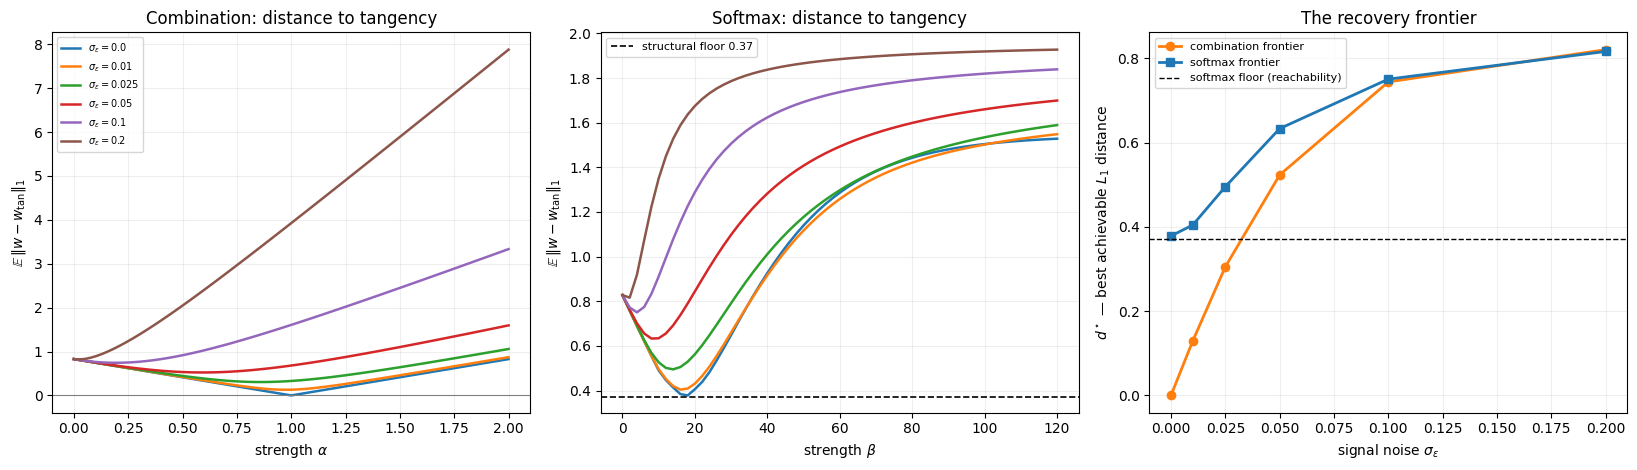

In [7]:
# ---- Experiment 4.6: fixed cross-section, targets, recovery surfaces ----
rng_fc = np.random.default_rng(4646)
mu_fc  = mu_bar + sigma_mu * rng_fc.standard_normal(N)
sig_fc = np.clip(0.20 + 0.05 * rng_fc.standard_normal(N), 0.05, None)
eta46  = rng_fc.standard_normal((n_sims, N))          # vol-signal noise for the GMV part

w_tan = (mu_fc / sig_fc**2); w_tan /= w_tan.sum()
w_gmv = (1.0 / sig_fc**2);  w_gmv /= w_gmv.sum()
print(f"fixed cross-section: {int((mu_fc < 0).sum())} of {N} drifts negative; "
      f"tangency shorts {int((w_tan < 0).sum())} names (min weight {w_tan.min():.3f}); "
      f"GMV is long-only (min weight {w_gmv.min():.3f})")

R_fc = np.exp((mu_fc - 0.5 * sig_fc**2) * dt + sig_fc * np.sqrt(dt) * phi) - 1.0

se_grid46 = [0.0, 0.01, 0.025, 0.05, 0.10, 0.20]
alpha_g46 = np.linspace(0.0, 2.0, 81)
beta_g46  = np.linspace(0.0, 120.0, 61)

# softmax structural floor: nearest point of the clean-signal family to the tangency target
floor_d = min(np.abs(softmax_weights(mu_fc[None, :], b)[0] - w_tan).sum()
              for b in np.linspace(0, 400, 801))
print(f"softmax structural floor (clean signal, tangency target): L1 = {floor_d:.3f} "
      f"(= {floor_d/2:.1%} turnover)\n")

def comb_recovery(se):
    s = mu_fc + se * eps0
    num = s / sig_fc**2
    ns = num.sum(axis=1)
    m = np.abs(ns) > 0.10 * np.median(np.abs(ns))
    w_sig = num[m] / ns[m, None]
    X = w_sig - 1.0 / N                                   # displacement of the leg
    a_vec = (1.0 / N) - w_tan                              # w_eq - target
    D1 = [np.abs(a_vec + a * X).sum(axis=1).mean() for a in alpha_g46]
    k = int(np.argmin(D1))
    a_rec_cf = -(a_vec * X.mean(axis=0)).sum() / (X**2).sum(axis=1).mean()   # closed form (L2)
    # CE at the L1 recovering strength vs the CE-optimal strength (stable region)
    R_m = R_fc[m]
    p_eq, p_sig = R_m.mean(axis=1), (w_sig * R_m).sum(axis=1)
    ce_a = []
    for a in alpha_g46:
        with np.errstate(over='ignore'):
            u = np.exp(-gamma * ((1 - a) * p_eq + a * p_sig))
        ce_a.append(-np.log(u.mean()) / gamma if u.max()/u.sum() < msh_max else -np.inf)
    ce_a = np.array(ce_a); k_ce = int(np.argmax(ce_a))
    regret = 1e4 * (ce_a[k_ce] - ce_a[k]) if np.isfinite(ce_a[k]) else np.nan
    return D1, alpha_g46[k], D1[k], a_rec_cf, alpha_g46[k_ce], regret

def sfmx_recovery(se):
    s = mu_fc + se * eps0
    D1 = [np.abs(softmax_weights(s, b) - w_tan).sum(axis=1).mean() for b in beta_g46]
    k = int(np.argmin(D1))
    ce_b = np.array([ce_of((softmax_weights(s, b) * R_fc).sum(axis=1)) for b in beta_g46])
    k_ce = int(np.argmax(ce_b))
    return D1, beta_g46[k], D1[k], beta_g46[k_ce], 1e4 * (ce_b[k_ce] - ce_b[k])

res_c = {se: comb_recovery(se) for se in se_grid46}
res_s = {se: sfmx_recovery(se) for se in se_grid46}

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
ax = axes[0]
for se in se_grid46:
    ax.plot(alpha_g46, res_c[se][0], lw=1.8, label=fr'$\sigma_\varepsilon={se}$')
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\alpha$'); ax.set_ylabel(r'$\mathbb{E}\,\|w-w_{\mathrm{tan}}\|_1$')
ax.set_title('Combination: distance to tangency')
ax.grid(alpha=0.2); ax.legend(fontsize=7)
ax = axes[1]
for se in se_grid46:
    ax.plot(beta_g46, res_s[se][0], lw=1.8)
ax.axhline(floor_d, color='black', ls='--', lw=1.2, label=f'structural floor {floor_d:.2f}')
ax.set_xlabel(r'strength $\beta$'); ax.set_ylabel(r'$\mathbb{E}\,\|w-w_{\mathrm{tan}}\|_1$')
ax.set_title('Softmax: distance to tangency')
ax.grid(alpha=0.2); ax.legend(fontsize=8)
ax = axes[2]
ax.plot(se_grid46, [res_c[se][2] for se in se_grid46], 'o-', lw=2, color='tab:orange',
        label='combination frontier')
ax.plot(se_grid46, [res_s[se][2] for se in se_grid46], 's-', lw=2, color='tab:blue',
        label='softmax frontier')
ax.axhline(floor_d, color='black', ls='--', lw=1, label='softmax floor (reachability)')
ax.set_xlabel(r'signal noise $\sigma_\varepsilon$')
ax.set_ylabel(r'$d^\star$ — best achievable $L_1$ distance')
ax.set_title('The recovery frontier')
ax.grid(alpha=0.2); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'sigma_eps':>10} | {'comb d*':>8} {'a_rec':>6} {'a_rec(cf)':>9} {'a_CE*':>6} {'regret bp':>9} | "
      f"{'sfmx d*':>8} {'b_rec':>6} {'b_CE*':>6} {'regret bp':>9}")
for se in se_grid46:
    Dc, ar, dc, cf, ace, rg = res_c[se]
    Ds, br, ds, bce, rgs = res_s[se]
    print(f"{se:>10} | {dc:>8.3f} {ar:>6.2f} {cf:>9.2f} {ace:>6.2f} {rg:>9.1f} | "
          f"{ds:>8.3f} {br:>6.0f} {bce:>6.0f} {rgs:>9.1f}")

In [8]:
# ---- GMV via the log-vol signal; block-split and cross-section robustness ----
# (a) GMV is ON the softmax family: softmax(beta * (-2 ln sighat)) = GMV exactly at beta=1, nu=0
print("(a) GMV recovery through the softmax log-vol signal")
beta_gmv = np.linspace(0.0, 2.0, 81)
for nu in [0.0, 0.05, 0.10, 0.20]:
    sighat = sig_fc * np.exp(nu * eta46 - 0.5 * nu**2)
    s_lv = -2.0 * np.log(sighat)
    D = [np.abs(softmax_weights(s_lv, b) - w_gmv).sum(axis=1).mean() for b in beta_gmv]
    k = int(np.argmin(D))
    print(f"  nu={nu}: min distance {D[k]:.4f} at beta_rec = {beta_gmv[k]:.2f}")

# (b) one seed vs many: split the 30k replications into 6 blocks (equivalent to 6 seeds)
print("\n(b) block-split stability of the baseline recovery numbers (sigma_eps = 0.05)")
se_b = 0.05
s_b = mu_fc + se_b * eps0
blocks = np.array_split(np.arange(n_sims), 6)
stats = []
for blk in blocks:
    D1 = [np.abs(softmax_weights(s_b[blk], b) - w_tan).sum(axis=1).mean() for b in beta_g46]
    k = int(np.argmin(D1)); stats.append((D1[k], beta_g46[k]))
d_blk = np.array([x[0] for x in stats]); b_blk = np.array([x[1] for x in stats])
print(f"  softmax d* across 6 blocks: mean {d_blk.mean():.3f}, sd {d_blk.std(ddof=1):.4f} "
      f"| beta_rec: mean {b_blk.mean():.0f}, sd {b_blk.std(ddof=1):.1f}")

# (c) the frozen cross-section is a conditioning choice: three alternative draws
print("\n(c) three alternative cross-sections (headline numbers at sigma_eps = 0.05)")
for seed in [4646, 4647, 4648]:
    r2 = np.random.default_rng(seed)
    m2 = mu_bar + sigma_mu * r2.standard_normal(N)
    s2 = np.clip(0.20 + 0.05 * r2.standard_normal(N), 0.05, None)
    wt = m2 / s2**2; wt /= wt.sum()
    fl = min(np.abs(softmax_weights(m2[None, :], b)[0] - wt).sum() for b in np.linspace(0, 400, 801))
    sg = m2 + se_b * eps0
    Ds = min(np.abs(softmax_weights(sg, b) - wt).sum(axis=1).mean() for b in beta_g46)
    num = sg / s2**2; ns = num.sum(axis=1)
    mm = np.abs(ns) > 0.10 * np.median(np.abs(ns))
    ws = num[mm] / ns[mm, None]
    Dc = min(np.abs((1/N - wt) + a * (ws - 1/N)).sum(axis=1).mean() for a in alpha_g46)
    print(f"  seed {seed}: shorts in tangency {int((wt<0).sum()):>2} | "
          f"softmax floor {fl:.3f}, d* {Ds:.3f} | combination d* {Dc:.3f}")

(a) GMV recovery through the softmax log-vol signal
  nu=0.0: min distance 0.0000 at beta_rec = 1.00
  nu=0.05: min distance 0.0741 at beta_rec = 0.93
  nu=0.1: min distance 0.1323 at beta_rec = 0.73
  nu=0.2: min distance 0.1990 at beta_rec = 0.43

(b) block-split stability of the baseline recovery numbers (sigma_eps = 0.05)
  softmax d* across 6 blocks: mean 0.633, sd 0.0005 | beta_rec: mean 8, sd 0.0

(c) three alternative cross-sections (headline numbers at sigma_eps = 0.05)
  seed 4646: shorts in tangency  4 | softmax floor 0.371, d* 0.633 | combination d* 0.523
  seed 4647: shorts in tangency  2 | softmax floor 0.473, d* 0.654 | combination d* 0.454
  seed 4648: shorts in tangency  3 | softmax floor 0.347, d* 0.660 | combination d* 0.617


**Reading.** The recovery question receives a quantitative answer, and the frontier splits exactly as predicted into reachability and noise. The **combination map** recovers plug-in Markowitz *exactly* at the clean limit ($d^\star = 0$ at $\alpha_{\mathrm{rec}} = 1.00$), and the simulated recovering strength then tracks the closed-form quadratic minimiser almost perfectly across the noise ladder ($0.98$ vs $0.97$; $0.85$ vs $0.85$; $0.60$ vs $0.56$; $0.20$ vs $0.15$) — a $\kappa$-shrinkage retreat, as the bias–variance argument anticipated: mimicking a fixed target through a noisier lens calls for a *gentler* tilt, because strength amplifies lens noise into weight dispersion. The **softmax** starts at its structural floor ($0.371$ in $L_1$, i.e.\ $18.6\%$ turnover — the price of the four short positions the family cannot express) and degrades from there; by $\sigma_\varepsilon = 0.1$ the two maps' frontiers nearly meet ($0.744$ vs $0.751$): **under serious noise, the reachability advantage is worthless** — the statistical part of the distance dominates the structural part. The GMV panel completes the reachability story in the other direction: fed the log-vol signal, the softmax hits GMV *exactly* at $\beta_{\mathrm{rec}} = 1.00$ with a clean vol signal, and $\beta_{\mathrm{rec}}$ then retreats ($0.93 \to 0.73 \to 0.43$) faster than the log-scale $\kappa$ — the Experiment 3.5 pattern reappearing on a distance objective.

The **recovery–optimality tension** is real, large, and — the honest surprise — present even without noise. On this cross-section the CE-optimal combination strength sits at the top of the stable grid ($\alpha \geq 2$) while exact recovery sits at $\alpha = 1$: holding the plug-in tangency portfolio costs $369$ bp *with perfect inputs*, because the fully invested, CARA-$\gamma{=}5$ investor optimally tilts well past the normalised tangency point. Noise then shrinks both strengths and the regret with them ($405 \to 77 \to 10$ bp): as the lens clouds, what utility wants and what mimicry wants converge — towards equal weight, from opposite motives. The classical framework, on this evidence, is a *point* the family passes through, not a destination it should stop at; with clean inputs it is identifiable but suboptimal, with noisy inputs unidentifiable but cheap to miss.

Both housekeeping checks close cleanly. The six-block split moves $d^\star$ by $\pm 0.0005$ and $\beta_{\mathrm{rec}}$ not at all — one seed at $30{,}000$ replications is statistically equivalent to six seeds at $5{,}000$, and the Monte-Carlo error on these quantities is negligible. Three alternative cross-sections reproduce every qualitative feature (positive softmax floor scaling with the number of unreachable shorts; combination $d^\star$ below softmax $d^\star$; same frontier shape), confirming that the frozen cross-section is a conditioning convenience, not a driver of the conclusions.

## Methodological notes

**Look-ahead, quarantined.** Experiments 4.1's signals (leakage, top-$k$) breach the firewall by construction; every use is labelled, and no cross-experiment comparison mixes firewalled and leaked signals except where the breach is the object of study. The clean-drift benchmark of 4.1 is computed on the same draws, so the ``top-5 beats clean drift'' comparison is paired.

**Interior optima and grid edges.** For firewalled signals every $\beta^\star$ reported is interior. For outcome-informed signals (4.1) the optimum sits at the grid edge *because the true optimum is at infinity* — $\Delta$CE is monotone in strength and the binding constraint is the signal's coarseness ceiling $\theta_{\max}(k)$, reported alongside. These edges are structural, unlike the stability-truncated edges of Chapter 3's combination sweeps, and the two should not be conflated.

**Estimator behaviour.** Experiments 4.1–4.3 and 4.5 are softmax-based and long-only: utility is bounded, no guard or tail diagnostic is required. Experiment 4.4's combination legs apply the Chapter 3 normaliser guard and stability threshold unchanged; its dropped counts are part of the result (the market loading inflates them by a factor of twenty).

**The ERM fixed point.** $w \propto \exp[(\beta s - \gamma_r \Sigma w)/\tau]$ is solved by damped iteration (damping $0.5$, tolerance $10^{-8}$), vectorised across replications; strict concavity for $\tau > 0$ guarantees the unique solution. The $\tau \to 0$ edge is not evaluated directly (the iteration stiffens); the mean--variance edge is instead represented by Chapter 3's combination results, and the softmax edge by direct evaluation at $\gamma_r = 0$ over the matched effective-strength range $\beta/\tau$.

**Common random numbers, inventory.** Seed 42 reproduces the Chapter 3 lab draw-for-draw; seeds 4242 and 7 reproduce Experiment 3.3/3.7's correlation structures, so the Experiment 4.5 edge values are paired with those chapters' results (and match them). New objects — the second signal's independent noise and the market component — use stream 4444 and touch nothing upstream. Experiment 4.2's noise pair is built from the *same* $\varepsilon_0$ as the baseline signal plus the new stream, so its $\rho = 0$ column is paired with Chapter 3's single-signal results.

**Numbering.** Experiments 4.1–4.5 follow the thesis chapter convention: Chapter 4 is the general framework, as 3.1–3.7 were the preliminary approaches.

**One seed or many.** A pseudo-random seed indexes a starting point in one i.i.d.\ stream, so several seeds of $n$ replications and one seed of $kn$ replications estimate the same quantities with the same distribution: more seeds is simply more replications. The meaningful questions are the size of the Monte-Carlo error — quantified throughout by paired delta-method standard errors — and whether fragile quantities (grid optima, tail-sensitive averages) are moved by a handful of draws, which the block-split diagnostic of Experiment 4.6(b) checks directly: splitting the 30{,}000 draws into six blocks is operationally identical to rerunning with six seeds. Distinct from both is Experiment 4.6's frozen cross-section, which is a *conditioning* choice, not an error question: redrawing it changes the target itself, so robustness there means alternative cross-sections (4.6(c)), not alternative seeds.